### 루브릭 1. Transformer와 비교해 변경이 필요한 부분을 서술
## Transformer vs GPT-1 변경 사항 서술
  
본 과제에서는 "Improving Language Understanding by Generative Pre-Training" 논문에 기반하여, 기존 Transformer 구조를 GPT-1 모델로 변경하여 구현합니다.
주요 변경사항은 아래와 같습니다.

1. 전체 구조: Encoder 제거 (Decoder-Only Architecture)
- 기존 Transformer: 입력 문장을 처리하는 Encoder와 출력 문장을 생성하는 Decoder가 결합된 구조입니다.

- GPT-1: 텍스트 생성을 목적으로 하는 모델이므로 Encoder를 완전히 제거하고, Decoder 블록만 적층하여 사용합니다.

2. Decoder Layer 내부 구조 단순화
- 기존 Transformer: Decoder 블록 내에 3개의 서브 레이어(Masked Self-Attention, Encoder-Decoder Attention, Feed-Forward)가 존재합니다.

- GPT-1: Encoder가 없으므로, 외부 정보를 참조하는 Encoder-Decoder Attention(Cross-Attention) 층을 제거합니다. 오직 Masked Multi-Head Self-Attention과 Feed-Forward Network 두 가지 서브 레이어만으로 구성됩니다.

3. 입력 데이터 전처리 (Input Transformation)
- 기존 Transformer: 질문(Source)은 Encoder에, 답변(Target)은 Decoder에 별도로 입력합니다.

- GPT-1: 모든 입력을 하나의 연속된 시퀀스로 처리합니다. 논문의 Task-specific input transformations에 따라, 질문과 답변을 구분자(Delimiter)로 연결하여 [Start] + 질문 + [Delim] + 답변 + [Extract] 형태의 단일 시퀀스로 변환하여 입력합니다.

4. 학습 목표 (Training Objective)
- 기존 Transformer: 주어진 입력에 대해 타겟 문장을 번역(Seq2Seq)하는 것이 목표입니다.

- GPT-1: 앞선 단어들을 바탕으로 다음에 올 단어를 예측(Next Token Prediction)하는 언어 모델링(Language Modeling)을 수행합니다. 따라서 정답 레이블(Target)은 입력 데이터를 한 칸씩 왼쪽으로 시프트(Shift) 한 형태가 됩니다.


In [2]:
## 필요한 도구들 출력
!pip install sentencepiece


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 27.6 MB/s eta 0:00:00


In [3]:
class PositionalEncoding(nn.Module):
    def __init__(self, position, d_model):
        super(PositionalEncoding, self).__init__()
        self.d_model = d_model
        self.position = position

        self.pos_encoding = self._build_pos_encoding(position, d_model)

    def _get_angles(self, position, i, d_model):
        return 1.0 / (10000.0 ** ((2.0 * (i // 2)) / d_model)) * position

    def _build_pos_encoding(self, position, d_model):
        pos = torch.arange(position, dtype=torch.float32).unsqueeze(1)
        i = torch.arange(d_model, dtype=torch.float32).unsqueeze(0)

        angle_rads = self._get_angles(pos, i, d_model)
        sines = torch.sin(angle_rads[:, 0::2])
        cosines = torch.cos(angle_rads[:, 1::2])

        pos_encoding = torch.zeros(position, d_model)
        pos_encoding[:, 0::2] = sines
        pos_encoding[:, 1::2] = cosines

        pos_encoding = pos_encoding.unsqueeze(0)  # shape: [1, position, d_model]
        return pos_encoding

    def forward(self, x):
        return x + self.pos_encoding[:, :x.size(1), :].to(x.device)

In [4]:
def scaled_dot_product_attention(query, key, value, mask=None):

    # 1) Q와 K의 내적을 통해 score(유사도) 계산
    # key.transpose(-1, -2): (batch_size, heads, depth, seq_len)
    # matmul 결과 shape: (batch_size, heads, seq_len, seq_len)
    matmul_qk = torch.matmul(query, key.transpose(-1, -2))

    # 2) depth에 따라 정규화
    depth = key.size(-1)  # depth = d_model / heads
    logits = matmul_qk / math.sqrt(depth)

    # 3) 마스크가 주어졌다면 -1e9(아주 작은 값)를 더해 소프트맥스에서 제외시키도록 함
    if mask is not None:
        # 텐서플로우: logits += (mask * -1e9)
        # 파이토치 동일 적용
        logits = logits + (mask * -1e9)

    # 4) 소프트맥스 계산해 attention weights 생성
    attention_weights = F.softmax(logits, dim=-1)

    # 5) attention weights와 value의 내적
    output = torch.matmul(attention_weights, value)

    return output, attention_weights

In [5]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, name="multi_head_attention"):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model

        # d_model은 num_heads로 나누어떨어져야 함
        assert d_model % num_heads == 0

        self.depth = d_model // num_heads

        # 파이토치에서 Dense는 nn.Linear로 대응
        self.query_dense = nn.Linear(d_model, d_model)
        self.key_dense = nn.Linear(d_model, d_model)
        self.value_dense = nn.Linear(d_model, d_model)

        self.out_dense = nn.Linear(d_model, d_model)

    def split_heads(self, x, batch_size):
        """
        x: (batch_size, seq_len, d_model)
        => (batch_size, num_heads, seq_len, depth) 형태로 변환
        """
        x = x.view(batch_size, -1, self.num_heads, self.depth)
        x = x.permute(0, 2, 1, 3)  # (batch_size, num_heads, seq_len, depth)
        return x

    def forward(self, query, key, value, mask=None):
        """
        query, key, value: (batch_size, seq_len, d_model)
        mask: (batch_size, 1, seq_len, seq_len) 등으로 broadcast 가능하도록 구성
        """
        batch_size = query.size(0)

        # Q, K, V에 각각 Linear 적용
        query = self.query_dense(query)
        key = self.key_dense(key)
        value = self.value_dense(value)

        # Head 분할
        query = self.split_heads(query, batch_size)
        key = self.split_heads(key, batch_size)
        value = self.split_heads(value, batch_size)

        # 스케일드 닷 프로덕트 어텐션
        scaled_attention, _ = scaled_dot_product_attention(query, key, value, mask)

        # (batch_size, num_heads, seq_len, depth) -> (batch_size, seq_len, num_heads, depth)
        scaled_attention = scaled_attention.permute(0, 2, 1, 3).contiguous()

        # 다시 (batch_size, seq_len, d_model)로 합치기
        concat_attention = scaled_attention.view(batch_size, -1, self.d_model)

        # 최종 Dense
        output = self.out_dense(concat_attention)
        return output


In [7]:
def create_padding_mask(x):
    # x == 0 위치를 찾아 float형 1로 변환
    mask = (x == 0).float()
    # (batch_size, seq_len) -> (batch_size, 1, 1, seq_len)
    mask = mask.unsqueeze(1).unsqueeze(2)
    return mask

x = torch.tensor([[1, 2, 0, 3, 0],
                  [0, 0, 0, 4, 5]])
mask = create_padding_mask(x)
print("입력 텐서 크기 :", x.shape)    # (2, 5)
print("생성된 마스크 크기 :", mask.shape)  # (2, 1, 1, 5)
print(mask)

입력 텐서 크기 : torch.Size([2, 5])
생성된 마스크 크기 : torch.Size([2, 1, 1, 5])
tensor([[[[0., 0., 1., 0., 1.]]],


        [[[1., 1., 1., 0., 0.]]]])


In [8]:
def create_look_ahead_mask(x):
    seq_len = x.size(1)

    # (seq_len, seq_len) 크기의 하삼각 행렬(tril) 생성 후 1에서 빼서
    # 상삼각이 1, 하삼각(자기 자신 포함)이 0이 되도록 설정
    # => 미래 토큰(자신 인덱스보다 큰 위치) 마스킹
    look_ahead_mask = 1 - torch.tril(torch.ones((seq_len, seq_len)))

    # 패딩 마스크 생성 (shape: (batch_size, 1, 1, seq_len))
    padding_mask = create_padding_mask(x)

    # look_ahead_mask: (seq_len, seq_len) -> (1, seq_len, seq_len)
    look_ahead_mask = look_ahead_mask.unsqueeze(0)
    # -> (1, seq_len, seq_len) -> (1, 1, seq_len, seq_len)
    look_ahead_mask = look_ahead_mask.unsqueeze(1)
    look_ahead_mask = look_ahead_mask.to(x.device)

    # look-ahead 마스크와 패딩 마스크를 합성 (둘 중 하나라도 1이면 마스킹)
    # 최종 shape은 브로드캐스팅으로 (batch_size, 1, seq_len, seq_len)
    combined_mask = torch.max(look_ahead_mask, padding_mask)
    return combined_mask

x = torch.tensor([[1, 2, 3, 4, 5]])
mask_1 = create_look_ahead_mask(x)
print("첫 번째 시퀀스:\n", mask_1, mask_1.shape)

첫 번째 시퀀스:
 tensor([[[[0., 1., 1., 1., 1.],
          [0., 0., 1., 1., 1.],
          [0., 0., 0., 1., 1.],
          [0., 0., 0., 0., 1.],
          [0., 0., 0., 0., 0.]]]]) torch.Size([1, 1, 5, 5])


## 인코더층 만드는 부분 삭제
- GPT-1 논문에 따르면, 이 모델은 Transformer Decoder만 사용함. 인코더는 번역기처럼 "입력문장(영어)"을 "문맥 벡터"로 압축하는 역할을 하는데, GPT는 그냥 텍스트를 쭉 읽으면서 다음 단어를 생성하는 모델이라서 인코더가 필요 없음.

----------------------- 삭제 되는 코드 부분-------------------
```
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super(EncoderLayer, self).__init__()
        self.mha = MultiHeadAttention(d_model, num_heads)  # 이전에 구현한 MHA
        self.dropout1 = nn.Dropout(dropout)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)

        # 피드포워드 부분 (Dense -> ReLU -> Dense)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.ReLU(),
            nn.Linear(ff_dim, d_model)
        )
        self.dropout2 = nn.Dropout(dropout)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)

    def forward(self, x, mask=None):
        # (1) 멀티 헤드 어텐션 (셀프 어텐션)
        attn_output = self.mha(x, x, x, mask)  # (batch_size, seq_len, d_model)
        attn_output = self.dropout1(attn_output)
        out1 = self.norm1(x + attn_output)     # 잔차 연결 + LayerNorm

        # (2) 피드포워드 신경망
        ffn_output = self.ffn(out1)            # (batch_size, seq_len, d_model)
        ffn_output = self.dropout2(ffn_output)
        out2 = self.norm2(out1 + ffn_output)   # 잔차 연결 + LayerNorm

        return out2

class Encoder(nn.Module):
    def __init__(self,
                 vocab_size,
                 num_layers,
                 ff_dim,
                 d_model,
                 num_heads,
                 dropout=0.1):
        super(Encoder, self).__init__()
        self.d_model = d_model

        # (1) 임베딩 레이어
        self.embedding = nn.Embedding(vocab_size, d_model)

        # (2) 포지셔널 인코딩
        self.pos_encoding = PositionalEncoding(position=vocab_size, d_model=d_model)

        self.dropout = nn.Dropout(dropout)

        # (3) EncoderLayer 쌓기
        self.enc_layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, x, mask=None):
        # (1) 임베딩 & sqrt(d_model)로 스케일링
        x = self.embedding(x) * math.sqrt(self.d_model)

        # (2) 포지셔널 인코딩 적용 + 드롭아웃
        x = self.pos_encoding(x)  # shape: (batch_size, seq_len, d_model)
        x = self.dropout(x)

        # (3) num_layers만큼 쌓아올린 EncoderLayer 통과
        for layer in self.enc_layers:
            x = layer(x, mask)

        return x
```
----------------------- 삭제 되는 코드 부분-------------------

### DEcoderLayer수정(Cross-Attention 제거)
- 중간에 있던 Self.encodec_mha (인코더-디코더 어텐션) 부분과 관련 정규화 층(norm2)를 삭제해야 됨. 기존 Trnasformer 코드는 아래와 같았음. * 수정된 코드와 비교
```
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super(DecoderLayer, self).__init__()

        # 첫 번째 서브 레이어 (디코더 내부 셀프 어텐션)
        self.self_mha = MultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)

        # 두 번째 서브 레이어 (인코더-디코더 어텐션) <- 이 부분 삭제
        self.encdec_mha = MultiHeadAttention(d_model, num_heads)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)

        # 세 번째 서브 레이어 (피드포워드 네트워크)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_dim),  # Dense(units=ff_dim)
            nn.ReLU(),                   # activation='relu'
            nn.Linear(ff_dim, d_model)   # Dense(units=d_model)
        )
        self.norm3 = nn.LayerNorm(d_model, eps=1e-6)

        # 드롭아웃
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)

    def forward(self, x, enc_outputs, look_ahead_mask=None, padding_mask=None):
        # 1) 셀프 어텐션 (디코더 내부)
        self_attn_out = self.self_mha(x, x, x, mask=look_ahead_mask)
        self_attn_out = self.dropout1(self_attn_out)
        out1 = self.norm1(x + self_attn_out)  # 잔차 연결 + LayerNorm

        # 2) 인코더-디코더 어텐션
        encdec_attn_out = self.encdec_mha(out1, enc_outputs, enc_outputs, mask=padding_mask)
        encdec_attn_out = self.dropout2(encdec_attn_out)
        out2 = self.norm2(out1 + encdec_attn_out)  # 잔차 연결 + LayerNorm

        # 3) 피드포워드 (Dense -> ReLU -> Dense)
        ffn_out = self.ffn(out2)
        ffn_out = self.dropout3(ffn_out)
        out3 = self.norm3(out2 + ffn_out)  # 잔차 연결 + LayerNorm

        return out3

```

In [34]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super(DecoderLayer, self).__init__()

        # 1) 셀프 어텐션 (Masked Multi-Head Attention)
        self.self_mha = MultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)

        # 2) 피드포워드 네트워크
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.ReLU(),
            nn.Linear(ff_dim, d_model)
        )
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)

        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x, look_ahead_mask):
        # 1) Masked Self Attention
        # [수정] 리턴값을 1개만 받도록 변경했습니다. (attn1, _ -> attn1)
        attn1 = self.self_mha(x, x, x, mask=look_ahead_mask)
        
        attn1 = self.dropout1(attn1)
        out1 = self.norm1(x + attn1)  # 잔차 연결 + Norm

        # 2) Feed Forward
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output)
        out2 = self.norm2(out1 + ffn_output) # 잔차 연결 + Norm

        return out2

### DEcoder수정 (인코더 입력 제거)
- 인코더로부터 오는 출력값을 받는 부분을 모두 지움
   기존 코드는 아래와 같음. * 수정된 코드와 비교
```
class Decoder(nn.Module):
    def __init__(self,
                 vocab_size,
                 num_layers,
                 ff_dim,
                 d_model,
                 num_heads,
                 dropout=0.1):
        super(Decoder, self).__init__()
        self.d_model = d_model

        # (1) 임베딩 레이어
        self.embedding = nn.Embedding(vocab_size, d_model)

        # (2) 포지셔널 인코딩
        # 실제 학습 시에는 최대 시퀀스 길이에 맞추어 쓰기도 함
        self.pos_encoding = PositionalEncoding(position=vocab_size, d_model=d_model)

        self.dropout = nn.Dropout(dropout)

        # (3) DecoderLayer 쌓기
        self.dec_layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, x, enc_outputs, look_ahead_mask=None, padding_mask=None):
        # (1) 임베딩 + sqrt(d_model)로 스케일링
        x = self.embedding(x) * math.sqrt(self.d_model)

        # (2) 포지셔널 인코딩 + 드롭아웃
        x = self.pos_encoding(x)    # (batch_size, tgt_seq_len, d_model)
        x = self.dropout(x)

        # (3) num_layers만큼 쌓인 DecoderLayer 통과
        for layer in self.dec_layers:
            x = layer(x, enc_outputs, look_ahead_mask, padding_mask)

        return x
```

In [35]:
class Decoder(nn.Module):
    def __init__(self, vocab_size, num_layers, ff_dim, d_model, num_heads, dropout=0.1):
        super(Decoder, self).__init__()
        self.d_model = d_model

        # 1) 임베딩
        self.embedding = nn.Embedding(vocab_size, d_model)

        # 2) 포지셔널 인코딩
        self.pos_encoding = PositionalEncoding(position=vocab_size, d_model=d_model)

        self.dropout = nn.Dropout(dropout)

        # 3) DecoderLayer 쌓기 (위에서 수정한 클래스 사용)
        self.dec_layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, x, look_ahead_mask): # 인자에서 enc_outputs, padding_mask 제거
        # 1) 임베딩 + 스케일링
        x = self.embedding(x) * math.sqrt(self.d_model)

        # 2) 포지셔널 인코딩 + 드롭아웃
        x = self.pos_encoding(x)
        x = self.dropout(x)

        # 3) 디코더 층 통과
        for layer in self.dec_layers:
            x = layer(x, look_ahead_mask) # 인코더 관련 인자 전달 안 함

        return x

In [36]:
import os
import urllib.request

url = "https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv"
filename = "ChatbotData.csv"

# 이미 파일이 없는 경우에만 다운로드
if not os.path.exists(filename):
    print(f"Downloading {filename} ...")
    urllib.request.urlretrieve(url, filename)
    print("Download complete.")
else:
    print(f"{filename} already exists.")

path_to_dataset = os.getcwd()
path_to_chatbot_csv = os.path.join(path_to_dataset, filename)

print("path_to_dataset:", path_to_dataset)
print("path_to_chatbot_csv:", path_to_chatbot_csv)

ChatbotData.csv already exists.
path_to_dataset: /home/jovyan/work/workplace/Exploration/Ex08
path_to_chatbot_csv: /home/jovyan/work/workplace/Exploration/Ex08/ChatbotData.csv


In [37]:
# 사용할 샘플의 최대 개수
MAX_SAMPLES = 50000
print(MAX_SAMPLES)

50000


In [38]:
def preprocess_sentence(sentence):
  # 입력받은 sentence를 소문자로 변경하고 양쪽 공백을 제거
  sentence = sentence.lower().strip()

  # 단어와 구두점(punctuation) 사이의 거리를 만듭니다.
  # 예를 들어서 "I am a student." => "I am a student ."와 같이
  # student와 온점 사이에 거리를 만듭니다.
  sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
  sentence = re.sub(r'[" "]+', " ", sentence)

  # (a-z, A-Z, ".", "?", "!", ",")를 제외한 모든 문자를 공백인 ' '로 대체합니다.
  sentence = re.sub(r"[^0-9a-zA-Z가-힣?.!,]+", " ", sentence)
  sentence = sentence.strip()
  return sentence
print("슝=3")

슝=3


In [39]:
sample_sentence = "안녕하세요? Hello! I'm a student😊, nice to meet you!"

preprocessed_sentence = preprocess_sentence(sample_sentence)
print(preprocessed_sentence)

안녕하세요 ? hello ! i m a student , nice to meet you !


In [40]:
import pandas as pd

def read_chatbot_data(path_to_chatbot_csv, max_samples=50000):
    pairs = []

    # 1) CSV 로드 (인코딩 유지)
    df = pd.read_csv(path_to_chatbot_csv, encoding="utf-8-sig")

    # 2) 컬럼 체크
    required_cols = {"Q", "A"}
    missing = required_cols - set(df.columns)
    if missing:
        raise KeyError(f"CSV에 필요한 컬럼이 없습니다: {missing}. 현재 컬럼: {list(df.columns)}")

    # 3) 결측치 제거 (NaN이 'nan' 문자열로 들어가는 것 방지)
    df = df.dropna(subset=["Q", "A"])

    # 4) 필요한 만큼만 사용 (MAX_SAMPLES 반영)
    df = df.iloc[:max_samples]

    for q_text, a_text in zip(df["Q"], df["A"]):
        q_text = preprocess_sentence(str(q_text))
        a_text = preprocess_sentence(str(a_text))
        pairs.append((q_text, a_text))

    return pairs


In [41]:
pairs = read_chatbot_data(path_to_chatbot_csv, max_samples=MAX_SAMPLES)

print('전체 샘플 수 :', len(pairs))

전체 샘플 수 : 11823


In [42]:
corpus_file = "clean_corpus.txt"
with open(corpus_file, 'w', encoding='utf-8') as f:
    for q, a in pairs:
        f.write(q + "\n")
        f.write(a + "\n")

In [43]:
spm.SentencePieceTrainer.Train(
    input=corpus_file,
    model_prefix="spm_chatbot",  # (변경) 학습 데이터에 맞게 prefix 이름만 변경
    vocab_size=8000,
    character_coverage=1.0,
    model_type="bpe",
    max_sentence_length=999999,
    bos_id=1,  # <s>
    eos_id=2,  # </s>
    pad_id=0,  # <pad>
    unk_id=3   # <unk>
)


sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: clean_corpus.txt
  input_format: 
  model_prefix: spm_chatbot
  model_type: BPE
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 1
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 999999
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 3
  bos_id: 1
  eos_id: 2
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential_privacy: 0
  differ

In [44]:
sp = spm.SentencePieceProcessor()
sp.Load("spm_chatbot.model") 

True

In [45]:
# 예제 문장
sentence = "나는 센텐스피스로 파이토치를 배운다."

sentence = preprocess_sentence(sentence)
print("전처리 후의 문장:", sentence)

# 1. 토크나이징 (subword 단위로 분할)
tokens = sp.encode(sentence, out_type=str)
print("Tokenized:", tokens)

# 2. 인코딩 (서브워드를 정수 ID로 변환)
encoded = sp.encode(sentence, out_type=int)
print("Encoded:", encoded)

# 3. 디코딩 (정수 ID → 원본 문장 복원)
decoded = sp.decode(encoded)
print("Decoded:", decoded)


전처리 후의 문장: 나는 센텐스피스로 파이토치를 배운다 .
Tokenized: ['▁나는', '▁센', '텐', '스피', '스로', '▁파', '이', '토', '치', '를', '▁배', '운', '다', '▁.']
Encoded: [688, 2332, 7126, 3604, 861, 860, 6778, 7397, 6950, 6835, 272, 6884, 6785, 4]
Decoded: 나는 센텐스피스로 파이토치를 배운다 .


### 루브릭 2. 모델의 입력 형태에 맞게 전처리 수행

- 기존 트랜스 포머는 번역기처럼 질문과 답변을 따로 넣어야 했지만, GPT는 텍스트 생성 모델이라서 질문과 답변을 한 줄로 이어 붙여야 함.
- 그래서 "질문 + [구분자] + 답변" 형태로 데이터를 변형해 줘야 함.

In [46]:
# 1. 특수 토큰 ID 정의
# SentencePiece 모델의 설정을 그대로 가져옵니다.
PAD_ID = sp.pad_id()           # 패딩 (0)
BOS_ID = sp.bos_id()           # 문장 시작 (1)
EOS_ID = sp.eos_id()           # 문장 끝 (2)
DELIM_ID = sp.get_piece_size() # 질문/답변 구분자 (단어장 크기 + 0번째 ID 사용)

print(f"Special Tokens - PAD: {PAD_ID}, BOS: {BOS_ID}, EOS: {EOS_ID}, DELIM: {DELIM_ID}")

class GPTChatbotDataset(Dataset):
    def __init__(self, pairs, sp, max_length=40):
        super(GPTChatbotDataset, self).__init__()
        self.sp = sp
        self.max_length = max_length
        self.data = []

        for q_text, a_text in pairs:
            # 1) 토크나이즈 (텍스트 -> 숫자 리스트)
            q_ids = sp.EncodeAsIds(q_text)
            a_ids = sp.EncodeAsIds(a_text)
            
            # 2) GPT 입력 형식 구성 (논문의 Input Transformation)
            # [START] + Question + [DELIM] + Answer + [EXTRACT/EOS]
            input_ids = [BOS_ID] + q_ids + [DELIM_ID] + a_ids + [EOS_ID]
            
            # 3) 길이 제한 (Truncation)
            if len(input_ids) > max_length:
                input_ids = input_ids[:max_length]
            
            # 4) 패딩 (Padding)
            # 남는 공간을 PAD_ID로 채움
            padding_len = max_length - len(input_ids)
            input_ids += [PAD_ID] * padding_len
            
            # 5) 데이터 저장
            # Next Token Prediction은 입력(x)과 정답(y)을 여기서 나누지 않고,
            # 모델 학습 단계에서 시프트(Shift)하여 처리합니다.
            self.data.append(torch.tensor(input_ids, dtype=torch.long))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

print("GPTChatbotDataset 정의 완료!")

Special Tokens - PAD: 0, BOS: 1, EOS: 2, DELIM: 8000
GPTChatbotDataset 정의 완료!


In [47]:
# 질문(Q)과 답변(A)을 합쳤으므로 길이를 넉넉하게 늘립니다 (40 -> 60)
MAX_LENGTH = 60

# 위에서 정의한 GPT용 데이터셋 클래스 사용
dataset = GPTChatbotDataset(pairs, sp, max_length=MAX_LENGTH)

# 데이터 로더 생성 (배치 크기 32, 셔플 True)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# 잘 만들어졌는지 첫 번째 배치 확인해보기
for batch in dataloader:
    print("배치 텐서 크기:", batch.size())  # 예상: [32, 60]
    print("첫 번째 샘플:", batch[0])
    break

배치 텐서 크기: torch.Size([32, 60])
첫 번째 샘플: tensor([   1,  289,  250,  325, 7013,    4, 8000, 2049,    4,    2,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0])


In [48]:
for batch in dataloader:
    print("배치 텐서 크기:", batch.size())  # 예상: [32, 60]
    print("첫 번째 샘플(숫자):", batch[0])
    
    # 숫자를 다시 글자로 바꿔서(Decode) 눈으로 확인하기
    # (특수 토큰들은 SentencePiece 모델에 없어서 깨져 보일 수 있으니 ID로 처리)
    decoded_text = []
    for token_id in batch[0].tolist():
        if token_id == 1: decoded_text.append("[BOS]")
        elif token_id == 2: decoded_text.append("[EOS]")
        elif token_id == 0: continue # 패딩은 무시
        elif token_id >= sp.get_piece_size(): decoded_text.append("[DELIM]") # 구분자
        else: decoded_text.append(sp.IdToPiece(token_id))
            
    print("\n첫 번째 샘플(텍스트):", ' '.join(decoded_text))
    break

배치 텐서 크기: torch.Size([32, 60])
첫 번째 샘플(숫자): tensor([   1, 1009, 6797,   63,  722, 6843, 1613,  184, 3553, 6784,   11, 8000,
        1820, 1061, 1384,   91, 1332,  355,    4,    2,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0])

첫 번째 샘플(텍스트): [BOS] ▁학교 에 ▁좋아하는 ▁여자애 의 ▁관심을 ▁어떻게 ▁끌 지 ▁? [DELIM] ▁우선 ▁자신이 ▁멋진 ▁사람이 ▁되어 ▁보세요 ▁. [EOS]


### 루브릭 4. GPT 모델을 정상적으로 구성하였다.
- 노드의 Transformer 코드를 수정하여 GPT1 모델을 구성합니다.
- 코드는 아래와 같이 3 부분을 수정하였다.
- 1. Encoder 삭제: self.encoder 정의와 실행 부분을 모두 삭제함.
  2. 입력 단순화: 질문과 답변이 이미 합쳐져 있으므로 forward 함수가 inputs 하나만 받음.
  3. 마스크: 복잡한 패딩 마스크들은 다 없애고, 미래의 정답을 못보게 하는 look_ahead_mask 하나만 남겼음.

기존의 Transformer 코드는 아래와 같습니다.
```
class Transformer(nn.Module):
    def __init__(self,
                 vocab_size,
                 num_layers,      # 인코더/디코더 층 수
                 units,           # feed-forward 네트워크의 중간 차원(ff_dim)
                 d_model,         # 임베딩 및 내부 표현 차원
                 num_heads,       # 멀티헤드 어텐션의 헤드 수
                 dropout=0.1):
        super(Transformer, self).__init__()

        # 인코더 (데이터셋(Cornell/Chatbot)과 무관)
        self.encoder = Encoder(
            vocab_size=vocab_size,
            num_layers=num_layers,
            ff_dim=units,
            d_model=d_model,
            num_heads=num_heads,
            dropout=dropout
        )

        # 디코더 (데이터셋(Cornell/Chatbot)과 무관)
        self.decoder = Decoder(
            vocab_size=vocab_size,
            num_layers=num_layers,
            ff_dim=units,
            d_model=d_model,
            num_heads=num_heads,
            dropout=dropout
        )

        # 최종 출력층: (d_model) -> (vocab_size)
        self.final_linear = nn.Linear(d_model, vocab_size)

    def forward(self, inputs, dec_inputs):
        # 1) 인코더 패딩 마스크 생성 (pad_id=0 전제)
        enc_padding_mask = create_padding_mask(inputs)  # (batch_size, 1, 1, src_seq_len)

        # 2) 디코더 look-ahead + 패딩 마스크
        look_ahead_mask = create_look_ahead_mask(dec_inputs)  # (batch_size, 1, tgt_seq_len, tgt_seq_len)

        # 3) 디코더에서 인코더 출력 쪽을 마스킹할 때 쓸 패딩 마스크
        dec_padding_mask = create_padding_mask(inputs)  # (batch_size, 1, 1, src_seq_len)

        # 4) 인코더 수행
        enc_outputs = self.encoder(
            x=inputs,
            mask=enc_padding_mask
        )  # (batch_size, src_seq_len, d_model)

        # 5) 디코더 수행
        dec_outputs = self.decoder(
            x=dec_inputs,            # (batch_size, tgt_seq_len)
            enc_outputs=enc_outputs, # (batch_size, src_seq_len, d_model)
            look_ahead_mask=look_ahead_mask,
            padding_mask=dec_padding_mask
        )  # (batch_size, tgt_seq_len, d_model)

        # 6) 최종 Linear
        logits = self.final_linear(dec_outputs)  # (batch_size, tgt_seq_len, vocab_size)
        return logits
```

In [49]:
class GPT(nn.Module):
    def __init__(self,
                 vocab_size,
                 num_layers,      # 디코더 층 수
                 units,           # feed-forward 네트워크의 중간 차원(ff_dim)
                 d_model,         # 임베딩 및 내부 표현 차원
                 num_heads,       # 멀티헤드 어텐션의 헤드 수
                 dropout=0.1):
        super(GPT, self).__init__()

        # [삭제됨] self.encoder = Encoder(...) -> GPT는 인코더가 없음.

        # [수정됨] 디코더 (앞서 수정한 Decoder 클래스 사용)
        self.decoder = Decoder(
            vocab_size=vocab_size,
            num_layers=num_layers,
            ff_dim=units,
            d_model=d_model,
            num_heads=num_heads,
            dropout=dropout
        )

        # 최종 출력층: (d_model) -> (vocab_size)
        self.final_linear = nn.Linear(d_model, vocab_size)

    def forward(self, inputs):
        # [변경점 1] 입력 인자: inputs, dec_inputs 2개 -> inputs 1개로 통합
        # (이미 질문+답변이 합쳐진 데이터가 들어옵니다)

        # [변경점 2] 마스크 생성
        # 인코더 패딩 마스크, 인코더-디코더 마스크는 필요 없습니다.
        # 오직 '다음 단어 예측'을 위한 look_ahead_mask만 필요합니다.
        look_ahead_mask = create_look_ahead_mask(inputs)

        # [삭제됨] 인코더 수행 부분 (enc_outputs = self.encoder(...))

        # [변경점 3] 디코더 수행
        # 인코더 출력(enc_outputs) 없이 입력과 마스크만 전달합니다.
        dec_outputs = self.decoder(
            x=inputs,
            look_ahead_mask=look_ahead_mask
        )

        # 최종 출력
        logits = self.final_linear(dec_outputs)
        return logits

### 루브릭 4. GPT 모델을 정상적으로 구성하였다
아래 출력물을 보았을 때 Encoder 없이 Decoder만 존재하는 구조를 완성함.

In [50]:
# 예: 하이퍼파라미터 설정
NUM_LAYERS = 2      # 층 수
D_MODEL = 256       # 임베딩 및 내부 표현 차원
NUM_HEADS = 8       # 헤드 수
UNITS = 512         # 피드포워드 신경망의 은닉 차원
DROPOUT = 0.1       # 드롭아웃 비율

# [수정 1] 단어장 크기 변경
# 기존 SentencePiece 크기에 우리가 추가한 DELIM 토큰(1개)을 더해줌<- 아니면 오류남
VOCAB_SIZE = sp.get_piece_size() + 1

# [수정 2] 모델 생성 (Transformer -> GPT)
# GPU가 있다면 GPU를 사용하도록 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = GPT(
    vocab_size=VOCAB_SIZE,
    num_layers=NUM_LAYERS,
    units=UNITS,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    dropout=DROPOUT
).to(device)

print(model)

GPT(
  (decoder): Decoder(
    (embedding): Embedding(8001, 256)
    (pos_encoding): PositionalEncoding()
    (dropout): Dropout(p=0.1, inplace=False)
    (dec_layers): ModuleList(
      (0-1): 2 x DecoderLayer(
        (self_mha): MultiHeadAttention(
          (query_dense): Linear(in_features=256, out_features=256, bias=True)
          (key_dense): Linear(in_features=256, out_features=256, bias=True)
          (value_dense): Linear(in_features=256, out_features=256, bias=True)
          (out_dense): Linear(in_features=256, out_features=256, bias=True)
        )
        (norm1): LayerNorm((256,), eps=1e-06, elementwise_affine=True)
        (ffn): Sequential(
          (0): Linear(in_features=256, out_features=512, bias=True)
          (1): ReLU()
          (2): Linear(in_features=512, out_features=256, bias=True)
        )
        (norm2): LayerNorm((256,), eps=1e-06, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=

In [51]:
loss_function = nn.CrossEntropyLoss(ignore_index=sp.pad_id())

In [52]:
def get_lr_lambda(d_model, warmup_steps=4000):
    d_model = float(d_model)
    def lr_lambda(step):
        # step은 0부터 시작하므로 +1로 보정
        step = step + 1
        return (d_model ** -0.5) * min(step ** -0.5, step * (warmup_steps ** -1.5))
    return lr_lambda

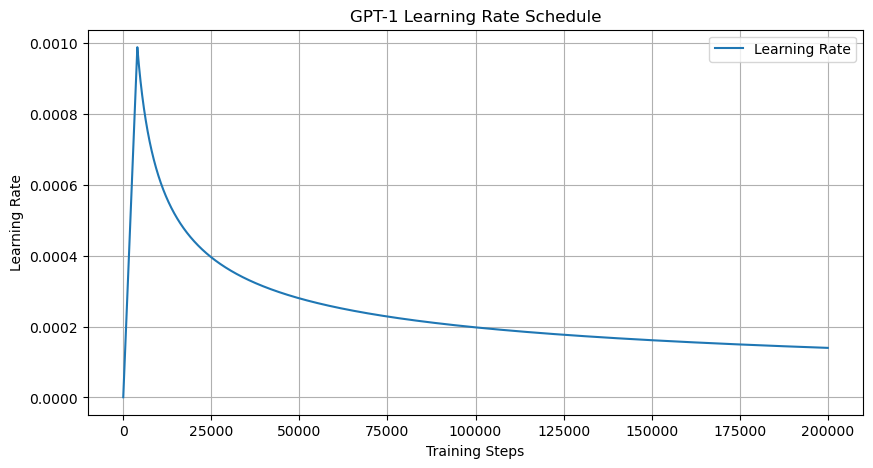

In [53]:
# 하이퍼파라미터 설정
d_model = D_MODEL  
warmup_steps = 4000
total_steps = 200000  # 총 학습 스텝

# 학습률 스케줄 시각화
steps = np.arange(1, total_steps + 1)
learning_rates = [get_lr_lambda(d_model, warmup_steps)(step) for step in steps]

# 그래프 출력
plt.figure(figsize=(10, 5))
plt.plot(steps, learning_rates, label="Learning Rate")
plt.xlabel("Training Steps")
plt.ylabel("Learning Rate")
plt.title("GPT-1 Learning Rate Schedule")
plt.legend()
plt.grid(True)
plt.show()


In [54]:
# Optimizer 정의
optimizer = optim.Adam(model.parameters(), betas=(0.9, 0.98), eps=1e-9)

# Scheduler 정의
scheduler = lr_scheduler.LambdaLR(optimizer, lr_lambda=get_lr_lambda(D_MODEL, warmup_steps=4000))

def accuracy_function(y_pred, y_true, pad_id=None):
    """
    y_pred: (batch_size, seq_len, vocab_size)
    y_true: (batch_size, seq_len)
    """
    if pad_id is None:                # (변경) pad_id를 sp에서 가져오도록
        pad_id = sp.pad_id()

    preds = y_pred.argmax(dim=-1)     # (batch_size, seq_len)
    mask = (y_true != pad_id)
    correct = (preds == y_true) & mask
    acc = correct.float().sum() / mask.float().sum()
    return acc

In [55]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = model.to(device)

### 루브릭3. 모델의 입력블록을 GPT 논문에 기반하여 수정
## train_step 함수 수정
- GPT는 "다음 단어 맞추기"이므로:
입력(Input): A B C
정답(Label): B C D (한 칸씩 밀림)
이렇게 데이터의 길이(Length)가 달라지기 때문에, 다음 단계인 train_step 함수에서 이 부분을 처리해 줄 것
- enc_input, dec_input, target = ... 부분이 사라지고 batch 하나만 받음.
- inputs와 targets를 슬라이싱([:-1], [1:])으로 생성함.
- model(inputs)로 호출함.

In [56]:
def train_step(model, batch, optimizer, loss_function, device):
    model.train()
    
    # [수정 1] 데이터 처리
    # 배치 전체를 GPU로 옮김
    batch = batch.to(device) # shape: (batch_size, seq_len)
    
    # 입력(inputs): 처음부터 마지막 토큰 전까지
    inputs = batch[:, :-1]
    
    # 정답(targets): 두 번째 토큰부터 끝까지 (Next Token Prediction)
    targets = batch[:, 1:]
    
    optimizer.zero_grad()
    
    # [수정 2] 모델 포워드 패스 (인자 1개)
    # 인코더 입력 없이 inputs만 들어갑니다.
    logits = model(inputs)  # (batch_size, seq_len-1, vocab_size)

    # [수정 3] Loss 계산
    # logits의 차원 변환: (N, L, C) -> (N, C, L) 형태로 맞춰줌
    loss = loss_function(logits.permute(0, 2, 1), targets)

    # Backpropagation
    loss.backward()
    optimizer.step()

    # 정확도 계산 (targets와 비교)
    return loss.item(), accuracy_function(logits, targets)

In [57]:
def train(model, dataloader, optimizer, loss_function, scheduler, num_epochs, device):
    print(f"Training started on {device}...")
    model.to(device)
    model.train() # 학습 모드 설정

    for epoch in range(num_epochs):
        total_loss = 0
        total_acc = 0
        
        for step, batch in enumerate(dataloader):
            # [중요] 우리가 수정한 GPT용 train_step을 호출합니다.
            # batch는 이제 (질문+답변)이 합쳐진 하나의 텐서입니다.
            loss, acc = train_step(model, batch, optimizer, loss_function, device)
            
            total_loss += loss
            total_acc += acc

            # 100 스텝마다 로그 출력
            if step % 100 == 0:
                print(f"[Epoch {epoch+1}, Step {step}] Loss: {loss:.4f}, Acc: {acc:.4f}")

            # 학습률 스케줄러 업데이트 (Step 단위)
            scheduler.step()

        # 에폭(Epoch) 종료 후 평균 결과 출력
        avg_loss = total_loss / len(dataloader)
        avg_acc = total_acc / len(dataloader)
        print(f"Epoch {epoch+1} Completed - Avg Loss: {avg_loss:.4f}, Avg Acc: {avg_acc:.4f}")
        print("-" * 50)

In [58]:
%%time

train(
    model=model,
    dataloader=dataloader,
    optimizer=optimizer,
    loss_function=loss_function,
    scheduler=scheduler,
    num_epochs=25,  # 원하는 에폭 수
    device=device
)

Training started on cuda...
[Epoch 1, Step 0] Loss: 9.1709, Acc: 0.0000
[Epoch 1, Step 100] Loss: 9.2056, Acc: 0.0000
[Epoch 1, Step 200] Loss: 9.2134, Acc: 0.0000
[Epoch 1, Step 300] Loss: 9.2065, Acc: 0.0000
Epoch 1 Completed - Avg Loss: 9.1986, Avg Acc: 0.0001
--------------------------------------------------
[Epoch 2, Step 0] Loss: 9.2139, Acc: 0.0000
[Epoch 2, Step 100] Loss: 9.2189, Acc: 0.0000
[Epoch 2, Step 200] Loss: 9.2241, Acc: 0.0000
[Epoch 2, Step 300] Loss: 9.1303, Acc: 0.0000
Epoch 2 Completed - Avg Loss: 9.1837, Avg Acc: 0.0001
--------------------------------------------------
[Epoch 3, Step 0] Loss: 9.2188, Acc: 0.0000
[Epoch 3, Step 100] Loss: 9.1329, Acc: 0.0000
[Epoch 3, Step 200] Loss: 9.1248, Acc: 0.0000
[Epoch 3, Step 300] Loss: 9.1157, Acc: 0.0000
Epoch 3 Completed - Avg Loss: 9.1547, Avg Acc: 0.0001
--------------------------------------------------
[Epoch 4, Step 0] Loss: 9.1339, Acc: 0.0000
[Epoch 4, Step 100] Loss: 9.1260, Acc: 0.0000
[Epoch 4, Step 200] L

In [59]:
def decoder_inference(model, sentence, sp, device='cpu'):
    # 1. 특수 토큰 정의
    BOS_ID = sp.bos_id()
    EOS_ID = sp.eos_id()
    DELIM_ID = sp.get_piece_size() # (추가) 질문과 답변 사이의 구분자
    MAX_LENGTH = 40

    # 2. 전처리
    sentence = preprocess_sentence(sentence)

    # 3. (변경) 입력 구성: [BOS] + 질문 + [DELIM]
    # 기존: enc_input(질문)과 dec_input(답변 시작)을 따로 만듦
    # 수정: 질문 뒤에 구분자(DELIM)를 붙여서 하나의 입력으로 만듦
    input_ids = [BOS_ID] + sp.EncodeAsIds(sentence) + [DELIM_ID]
    
    # 텐서 변환 (Batch size = 1)
    input_tensor = torch.tensor([input_ids], dtype=torch.long).to(device)

    model.eval()
    with torch.no_grad():
        for i in range(MAX_LENGTH):
            # 4. (변경) 모델 실행
            # 기존: logits = model(enc_input, dec_input) -> 인자가 2개였음
            # 수정: logits = model(input_tensor)         -> 인자가 1개로 통합됨
            logits = model(input_tensor) 

            # 마지막 토큰(다음 단어) 예측
            last_step_logits = logits[:, -1, :]
            predicted_id = torch.argmax(last_step_logits, dim=-1)

            # [EOS]가 나오면 종료
            if predicted_id.item() == EOS_ID:
                break

            # 5. (변경) 다음 입력 업데이트
            # 예측된 단어를 입력 텐서 뒤에 붙여서 다음 스텝으로 넘김
            predicted_id = predicted_id.unsqueeze(0)
            input_tensor = torch.cat([input_tensor, predicted_id], dim=1)

    # 결과 반환 (리스트 형태)
    output_sequence = input_tensor.squeeze(0).tolist()
    return output_sequence

In [60]:
def sentence_generation(model, sentence, sp, device='cpu'):
    # 1. 모델이 생성한 전체 시퀀스를 가져옵니다. (질문 + 답변)
    output_seq = decoder_inference(model, sentence, sp, device=device)

    # 2. 질문과 답변을 가르는 구분자(DELIM) ID 가져오기
    DELIM_ID = sp.get_piece_size()

    # 3. 구분자 뒤쪽(답변)만 잘라내기
    try:
        # DELIM 토큰의 위치를 찾아서 그 다음부터 가져옴
        delim_index = output_seq.index(DELIM_ID)
        answer_seq = output_seq[delim_index + 1:]
    except ValueError:
        # 혹시 구분자가 없으면 전체 출력
        answer_seq = output_seq

    # 4. 텍스트로 변환 (SentencePiece 범위 내의 토큰만 디코딩)
    predicted_sentence = sp.DecodeIds(
        [token for token in answer_seq if token < sp.get_piece_size()]
    )

    print("입력 :", sentence)
    print("출력 :", predicted_sentence)
    return predicted_sentence

### 루브릭5. 입력에 따른 출력이 생성되었다. 
- 출력 결과물의 수준에 상관없이 모델이 정상적으로 동작하였음.
- 에폭을 늘려보거나 하이퍼파라미터를 수정하면 더 좋은 결과를 예상해 볼 수 있음
  why? 에폭수에 따라 loss가 점점 떨어졌으므로

In [63]:
# 챗봇 테스트
sentence_generation(model, "12시 땡!", sp, device)
sentence_generation(model, "지루하다", sp, device)

입력 : 12시 땡!
출력 : .
입력 : 지루하다
출력 : .


'.'